# 03c — Pooling temporal y mezcla de niveles wav2vec

Este notebook define la representación SSL de referencia antes de incorporar una rama espectral. Compara, bajo los **mismos outer folds speaker-independent**, cuatro configuraciones:

```text
average_mean_std
learned_layers_mean_std
average_attention_statistics
learned_layers_attention_statistics
```

La métrica principal es **balanced accuracy** en todo el flujo: early stopping, selección de configuraciones, análisis por seed y criterio de cierre.

El encoder wav2vec permanece congelado. Los test finales no se cargan ni se utilizan.

## Formulación de las representaciones temporales multicapa

Sea una emisión de audio $x_i$. El encoder wav2vec 2.0 produce, para cada nivel $l$, una secuencia:

$$
H_i^{(l)} = (h_{i,1}^{(l)}, \dots, h_{i,T_i}^{(l)}) \in \mathbb{R}^{T_i \times D}
$$

donde:

* $i$: audio
* $l \in {1,\dots,L}$: nivel
* $T_i$: número de frames
* $D=768$: dimensión
* $L=13$: capas totales

### Estadísticas por nivel

Media:
$$
\mu_i^{(l)} = \frac{1}{T_i} \sum_{t} h_{i,t}^{(l)}
$$

Desvío:
$$
\sigma_i^{(l)} = \sqrt{\frac{1}{T_i} \sum_{t} (h_{i,t}^{(l)} - \mu_i^{(l)})^2}
$$

---

## 1. `average_mean_std`

Promedio simple entre capas:

$$
\bar{\mu}_i = \frac{1}{L} \sum_l \mu_i^{(l)}, \quad
\bar{\sigma}_i = \frac{1}{L} \sum_l \sigma_i^{(l)}
$$

Representación:
$$
z_i = (\bar{\mu}_i, \bar{\sigma}_i) \in \mathbb{R}^{1536}
$$

Sin parámetros aprendidos.

---

## 2. `learned_layers_mean_std`

Vector por capa:
$$
s_i^{(l)} = (\mu_i^{(l)}, \sigma_i^{(l)})
$$

Estandarización:
$$
\tilde{s} = \frac{s - m}{q}
$$

Pesos aprendidos:
$$
\beta_l = \frac{e^{a_l}}{\sum_j e^{a_j}}
$$

Combinación:
$$
z_i = \sum_l \beta_l \tilde{s}_i^{(l)} \in \mathbb{R}^{1536}
$$

Luego:
LayerNorm → Dropout → Linear

---

## 3. `average_attention_statistics`

Promedio entre capas:
$$
u_{i,t} = \frac{1}{L} \sum_l h_{i,t}^{(l)}
$$

Atención:
$$
e_{i,t} = w_2^\top \tanh(W_1 u_{i,t} + b_1) + b_2
$$

$$
\alpha_{i,t} = \text{softmax}(e_{i,t})
$$

Media:
$$
\mu_i = \sum_t \alpha_{i,t} u_{i,t}
$$

Desvío:
$$
\sigma_i = \sqrt{\sum_t \alpha_{i,t} (u_{i,t} - \mu_i)^2}
$$

Representación:
$$
z_i = (\mu_i, \sigma_i) \in \mathbb{R}^{1536}
$$

---

## 4. `learned_layers_attention_statistics`

Pesos entre capas:
$$
\beta_l = \text{softmax}(a_l)
$$

Combinación:
$$
u_{i,t} = \sum_l \beta_l h_{i,t}^{(l)}
$$

Atención igual que antes:

$$
\alpha_{i,t} = \text{softmax}(e_{i,t})
$$

Media y desvío:
$$
\mu_i = \sum_t \alpha_{i,t} u_{i,t}, \quad
\sigma_i = \sqrt{\sum_t \alpha_{i,t} (u_{i,t} - \mu_i)^2}
$$

Representación:
$$
z_i \in \mathbb{R}^{1536}
$$

---

## Resumen

* `average_mean_std`: estadísticas → promedio capas
* `learned_layers_mean_std`: estadísticas → mezcla aprendida
* `average_attention_statistics`: promedio capas → atención
* `learned_layers_attention_statistics`: mezcla capas → atención

## 1. Configuración y artefactos

Los bloques costosos permanecen activados mediante flags independientes. La persistencia se centraliza en `src/evaluation/temporal_results.py`, evitando funciones locales, variables globales y CSV redundantes.

Cuando `include_feature_projection=true`, los 13 índices corresponden a:

```text
índice 0: feature projection
índices 1–12: capas Transformer
```

In [ ]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config.contracts import (
    PROTOCOL_INDEPENDENT,
    TARGET_EMOTION_ORIGINAL,
    TARGET_EMOTION_ORIGINAL_EVAL_QUADRANT,
    TARGET_EMOTION_QUADRANT,
)
from src.evaluation.temporal_results import (
    TemporalArtifactPaths,
    load_temporal_artifacts,
    merge_experiment_output,
    persist_temporal_artifacts,
    select_best_configuration,
    select_oof_predictions,
    select_primary_results,
    summarize_primary_results,
)
from src.experiments.temporal_representation import (
    load_attention_weights,
    run_average_attention_cv,
    run_layer_mixture_grid,
    run_learned_layer_attention_cv,
    run_static_pooling_grid,
    save_attention_weights,
)
from src.features.wav2vec_temporal import (
    extract_or_load_temporal_features,
    load_layer_statistics,
)
from src.utils.config import get_config, resolve_path
from src.utils.io import load_metadata, load_splits
from src.utils.reproducibility import set_global_seed
from src.utils.temporal_visualization import (
    plot_attention_diagnostics,
    plot_confusion_comparison,
    plot_fold_and_seed_variability,
    plot_layer_weights,
    plot_metric_summary,
    plot_temporal_examples,
    select_temporal_examples,
)

cfg = get_config()
set_global_seed(int(cfg.seed))

PRIMARY_METRIC = str(cfg.metrics.primary)
if PRIMARY_METRIC != "balanced_accuracy":
    raise ValueError(
        "Este notebook requiere balanced_accuracy como métrica principal; "
        f"config.yaml declara {PRIMARY_METRIC!r}."
    )

metadata = load_metadata(cfg.paths.metadata)
splits = load_splits(cfg.paths.splits)

REPORTS_DIR = resolve_path(cfg.paths.reports_dir)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

STATS_PATH = resolve_path(cfg.temporal_representation.layer_statistics_path)
SEQUENCES_DIR = resolve_path(cfg.temporal_representation.sequences_dir)
MULTILAYER_SEQUENCES_DIR = resolve_path(
    cfg.temporal_representation.multilayer_sequences_dir
)

artifact_paths = TemporalArtifactPaths(
    results=REPORTS_DIR / "temporal_representation_results.csv",
    predictions=REPORTS_DIR / "temporal_oof_predictions.csv",
    layer_weights=REPORTS_DIR / "layer_mixture_weights.csv",
    attention_diagnostics=REPORTS_DIR / "attention_diagnostics.csv",
    attention_weights=REPORTS_DIR / "attention_weights_multilayer.npz",
)

RUN_FEATURE_EXTRACTION = False
RUN_STATIC_POOLING = False
RUN_LAYER_MIXTURE = False
RUN_AVERAGE_ATTENTION = False
RUN_LEARNED_LAYER_ATTENTION = False
RUN_SECONDARY_TARGETS = False

TARGETS = [TARGET_EMOTION_ORIGINAL]
if RUN_SECONDARY_TARGETS:
    TARGETS += [
        TARGET_EMOTION_QUADRANT,
        TARGET_EMOTION_ORIGINAL_EVAL_QUADRANT,
    ]

PROTOCOLS = [PROTOCOL_INDEPENDENT]
ACTIVE_CONFIGURATIONS = [
    "average_mean_std",
    "learned_layers_mean_std",
    "average_attention_statistics",
    "learned_layers_attention_statistics",
]
ATTENTION_CONFIGURATIONS = [
    "average_attention_statistics",
    "learned_layers_attention_statistics",
]
LABELS = list(dict(cfg.emotion_mapping.code_to_name).values())

artifacts = load_temporal_artifacts(
    artifact_paths,
    load_attention_weights_fn=load_attention_weights,
)

print(f"Metadata: {len(metadata)} audios")
print(f"Métrica principal: {PRIMARY_METRIC}")
print(f"Targets: {TARGETS}")
print(f"Resultados cargados: {len(artifacts.results)}")
print(f"Predicciones OOF cargadas: {len(artifacts.predictions)}")

Metadata: 1440 audios
Métrica principal: balanced_accuracy
Targets: ['emotion_original']
Resultados cargados: 560
Predicciones OOF cargadas: 48976


## 2. Extracción congelada de hidden states multicapa

La extracción genera artefactos por `file_id` sin utilizar targets ni folds:

```text
estadísticas por nivel: [audios, niveles, hidden]
secuencia multicapa:    [niveles, frames, hidden]
```

Los audios de distinta duración se mantienen como secuencias ragged. El `collate` aplica padding solo dentro de cada batch y construye una máscara temporal para excluir frames agregados.

In [2]:
if RUN_FEATURE_EXTRACTION:
    temporal_stats = extract_or_load_temporal_features(
        metadata=metadata,
        statistics_path=STATS_PATH,
        sequences_dir=SEQUENCES_DIR,
        multilayer_sequences_dir=MULTILAYER_SEQUENCES_DIR,
        path_col="file_path_trimmed",
        model_name=cfg.features.wav2vec.model_name,
        revision=cfg.features.wav2vec.revision,
        target_sample_rate=int(cfg.audio.target_sample_rate),
        include_feature_projection=bool(
            cfg.temporal_representation.include_feature_projection
        ),
        sequence_dtype=str(cfg.temporal_representation.sequence_dtype),
        overwrite=False,
    )
else:
    temporal_stats = (
        load_layer_statistics(
            STATS_PATH,
            expected_file_ids=metadata["file_id"],
        )
        if STATS_PATH.exists()
        else None
    )

if temporal_stats is None:
    raise RuntimeError(
        "No hay estadísticas multicapa. Active RUN_FEATURE_EXTRACTION."
    )

multi_count = len(list(MULTILAYER_SEQUENCES_DIR.glob("*.pt")))
print(
    f"{temporal_stats.n_files} audios · "
    f"{temporal_stats.n_layers} niveles · "
    f"{temporal_stats.hidden_size} dimensiones · "
    f"{multi_count} secuencias multicapa"
)

1440 audios · 13 niveles · 768 dimensiones · 1440 secuencias multicapa


## 3. Ejecución de las cuatro configuraciones

El early stopping de los modelos aprendidos se resuelve con una partición interna agrupada por actor dentro de cada outer train. Luego se reentrena sobre todo el outer train durante el número de épocas seleccionado y se evalúa una sola vez sobre el outer validation.

Las predicciones persistidas corresponden al ensemble entre seeds. Las filas individuales por seed permanecen en `temporal_representation_results.csv` y se usan para medir estabilidad de inicialización mediante balanced accuracy.

In [3]:
if RUN_STATIC_POOLING:
    static_output = run_static_pooling_grid(
        stats=temporal_stats,
        metadata=metadata,
        splits=splits,
        logistic_regression_config=dict(cfg.models.logistic_regression),
        seed=int(cfg.seed),
        layer_strategies=["average"],
        poolings=["mean_std"],
        protocols=PROTOCOLS,
        targets=TARGETS,
        n_folds=int(cfg.splits.cv_folds),
    )
    static_output["fold_results"] = static_output["fold_results"].assign(
        seed=-1,
        result_type="deterministic",
    )
    artifacts = merge_experiment_output(artifacts, static_output)
    persist_temporal_artifacts(
        artifacts,
        artifact_paths,
        save_attention_weights_fn=save_attention_weights,
    )

if RUN_LAYER_MIXTURE:
    layer_cfg = cfg.temporal_representation.layer_mixture
    layer_output = run_layer_mixture_grid(
        stats=temporal_stats,
        metadata=metadata,
        splits=splits,
        seeds=list(layer_cfg.seeds),
        poolings=["mean_std"],
        protocols=PROTOCOLS,
        targets=TARGETS,
        learning_rate=float(layer_cfg.learning_rate),
        weight_decay=float(layer_cfg.weight_decay),
        max_epochs=int(layer_cfg.max_epochs),
        patience=int(layer_cfg.patience),
        inner_folds=3,
        n_folds=int(cfg.splits.cv_folds),
    )
    artifacts = merge_experiment_output(artifacts, layer_output)
    persist_temporal_artifacts(
        artifacts,
        artifact_paths,
        save_attention_weights_fn=save_attention_weights,
    )

In [4]:
att_cfg = cfg.temporal_representation.attentive_pooling

attention_common = dict(
    metadata=metadata,
    splits=splits,
    multilayer_sequences_dir=MULTILAYER_SEQUENCES_DIR,
    seeds=list(att_cfg.seeds),
    protocols=PROTOCOLS,
    targets=TARGETS,
    n_layers=int(temporal_stats.n_layers),
    input_dim=int(temporal_stats.hidden_size),
    attention_hidden_dim=int(att_cfg.attention_hidden_dim),
    dropout=float(att_cfg.dropout),
    learning_rate=float(att_cfg.learning_rate),
    weight_decay=float(att_cfg.weight_decay),
    max_epochs=int(att_cfg.max_epochs),
    patience=int(att_cfg.patience),
    batch_size=int(att_cfg.batch_size),
    gradient_clip_norm=float(att_cfg.gradient_clip_norm),
    inner_folds=int(att_cfg.inner_folds),
    n_folds=int(cfg.splits.cv_folds),
)

if RUN_AVERAGE_ATTENTION:
    average_attention_output = run_average_attention_cv(
        **attention_common
    )
    artifacts = merge_experiment_output(
        artifacts,
        average_attention_output,
    )
    persist_temporal_artifacts(
        artifacts,
        artifact_paths,
        save_attention_weights_fn=save_attention_weights,
    )

if RUN_LEARNED_LAYER_ATTENTION:
    learned_attention_output = run_learned_layer_attention_cv(
        **attention_common
    )
    artifacts = merge_experiment_output(
        artifacts,
        learned_attention_output,
    )
    persist_temporal_artifacts(
        artifacts,
        artifact_paths,
        save_attention_weights_fn=save_attention_weights,
    )

## 4. Resumen principal

La tabla es la fuente de verdad para el notebook. Reporta media y desvío estándar muestral entre outer folds (`ddof=1`).

La selección de configuraciones, matrices y criterio de cierre utiliza exclusivamente **balanced accuracy**.

In [5]:
artifacts = load_temporal_artifacts(
    artifact_paths,
    load_attention_weights_fn=load_attention_weights,
)

primary_all = select_primary_results(
    artifacts.results,
    protocol=PROTOCOL_INDEPENDENT,
    target=TARGET_EMOTION_ORIGINAL,
    configurations=ACTIVE_CONFIGURATIONS,
    include_seed_rows=True,
)
primary_ensemble = select_primary_results(
    artifacts.results,
    protocol=PROTOCOL_INDEPENDENT,
    target=TARGET_EMOTION_ORIGINAL,
    configurations=ACTIVE_CONFIGURATIONS,
    include_seed_rows=False,
)
summary = summarize_primary_results(
    primary_ensemble,
    metric=PRIMARY_METRIC,
)
best_attention = select_best_configuration(
    summary,
    ATTENTION_CONFIGURATIONS,
)

if summary.empty:
    raise RuntimeError(
        "No hay resultados completos para las configuraciones primarias."
    )

display(
    summary.style.format(
        {
            "metric_mean": "{:.3f}",
            "metric_std": "{:.3f}",
            "worst_fold": "{:.3f}",
            "best_fold": "{:.3f}",
        }
    )
)
print(f"Mejor variante de atención por balanced accuracy: {best_attention}")

,refinement,metric_mean,metric_std,worst_fold,best_fold,n_folds
0,average_mean_std,0.736,0.049,0.672,0.801,5
1,learned_layers_mean_std,0.716,0.047,0.648,0.781,5
2,average_attention_statistics,0.680,0.062,0.613,0.762,5
3,learned_layers_attention_statistics,0.677,0.072,0.605,0.773,5


Mejor variante de atención por balanced accuracy: average_attention_statistics


### Lectura

La media resume rendimiento global, mientras que el desvío y el peor fold muestran sensibilidad a la composición de hablantes. Una mejora pequeña de media no es suficiente si se obtiene a costa de una degradación marcada en un subconjunto de actores.

El patrón compartido entre configuraciones también permite distinguir si el límite proviene del pooling o de la dificultad intrínseca de ciertos folds.

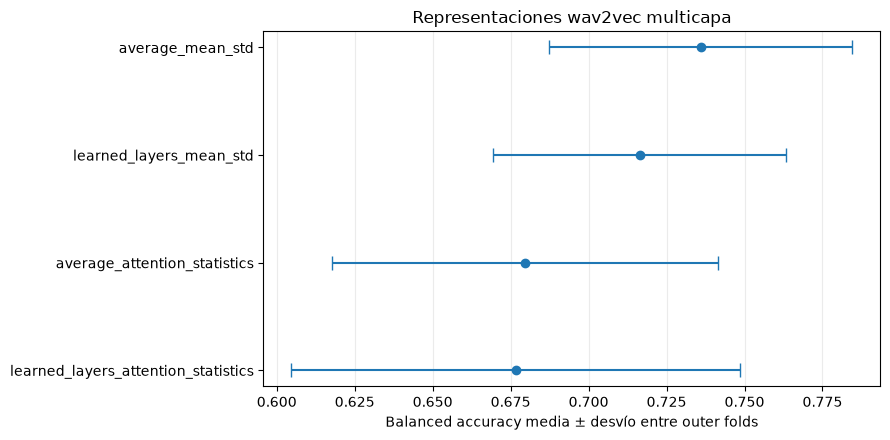

In [6]:
fig, _ = plot_metric_summary(
    summary,
    metric_label="Balanced accuracy",
    title="Representaciones wav2vec multicapa",
)
plt.show()

## 5. Estabilidad entre folds y seeds

El panel izquierdo muestra cada outer fold sin interpretar los folds como una secuencia temporal. El panel derecho calcula, para cada fold, el desvío de balanced accuracy entre seeds.

La referencia determinista no aparece en el panel de seeds porque no depende de inicialización neural.

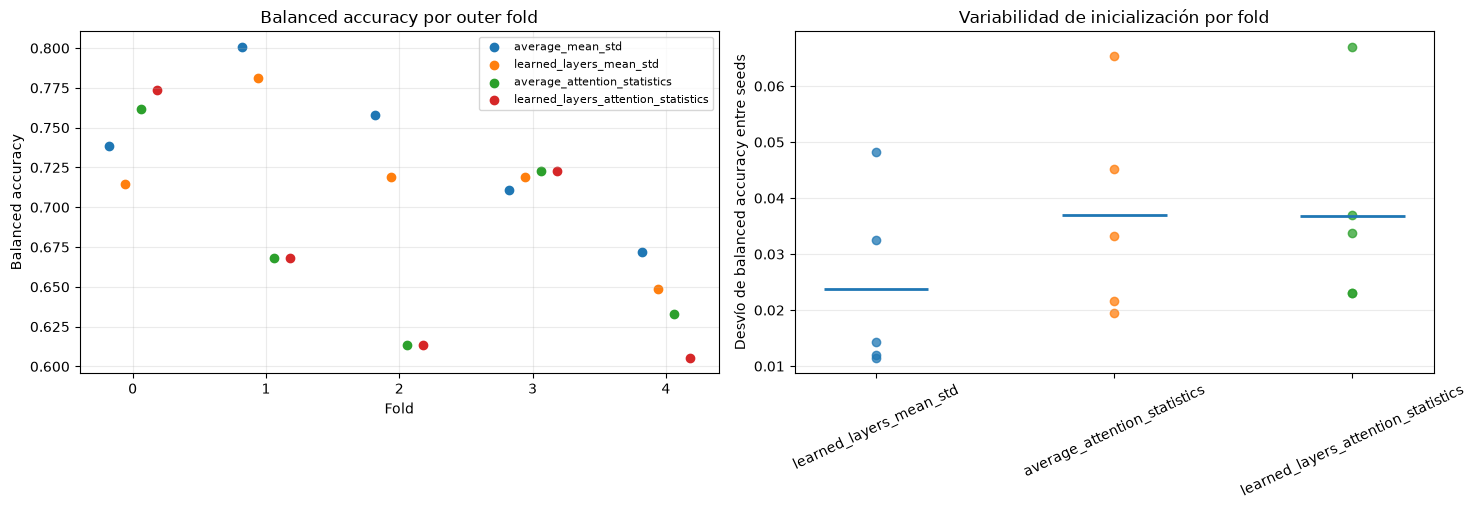

In [7]:
fig, _ = plot_fold_and_seed_variability(
    primary_all,
    configurations=ACTIVE_CONFIGURATIONS,
    metric=PRIMARY_METRIC,
    metric_label="Balanced accuracy",
)
plt.show()

## 6. Pesos aprendidos entre niveles wav2vec

La línea discontinua representa el promedio uniforme `1 / n_levels`. Separaciones estables respecto de esa referencia indican una preferencia relativa de la arquitectura.

Los pesos no deben interpretarse como importancia acústica absoluta: la mezcla tabular estandariza estadísticas por nivel, mientras que la mezcla secuencial opera directamente sobre hidden states. Por eso, la comparación válida es el perfil dentro de cada arquitectura.

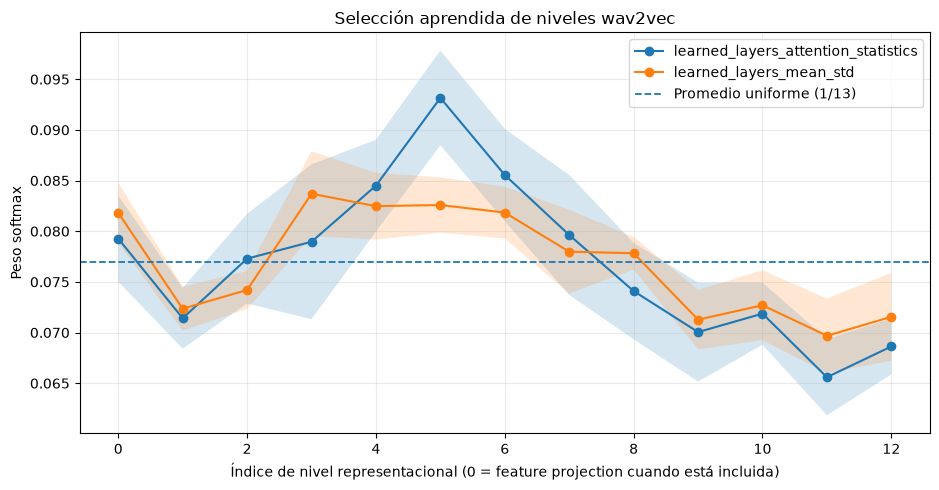

In [8]:
if artifacts.layer_weights.empty:
    print("Sin pesos aprendidos de niveles.")
else:
    fig, _ = plot_layer_weights(
        artifacts.layer_weights,
        configurations=[
            "learned_layers_mean_std",
            "learned_layers_attention_statistics",
        ],
        protocol=PROTOCOL_INDEPENDENT,
        target=TARGET_EMOTION_ORIGINAL,
        n_layers=int(temporal_stats.n_layers),
    )
    plt.show()

### Lectura

Un perfil casi uniforme sugiere que el modelo no encuentra suficiente evidencia para privilegiar niveles particulares. Picos moderados y repetibles pueden indicar especialización parcial, pero solo adquieren valor predictivo si se acompañan de mejoras consistentes en balanced accuracy y estabilidad.

## 7. Concentración de la atención temporal

La entropía normalizada cercana a uno corresponde a una atención difusa. Un máximo alto o una fracción pequeña de frames para acumular el 50 % de la masa corresponde a una atención más concentrada.

Estas métricas describen el comportamiento del pooling; no demuestran que los frames atendidos sean causalmente emocionales.

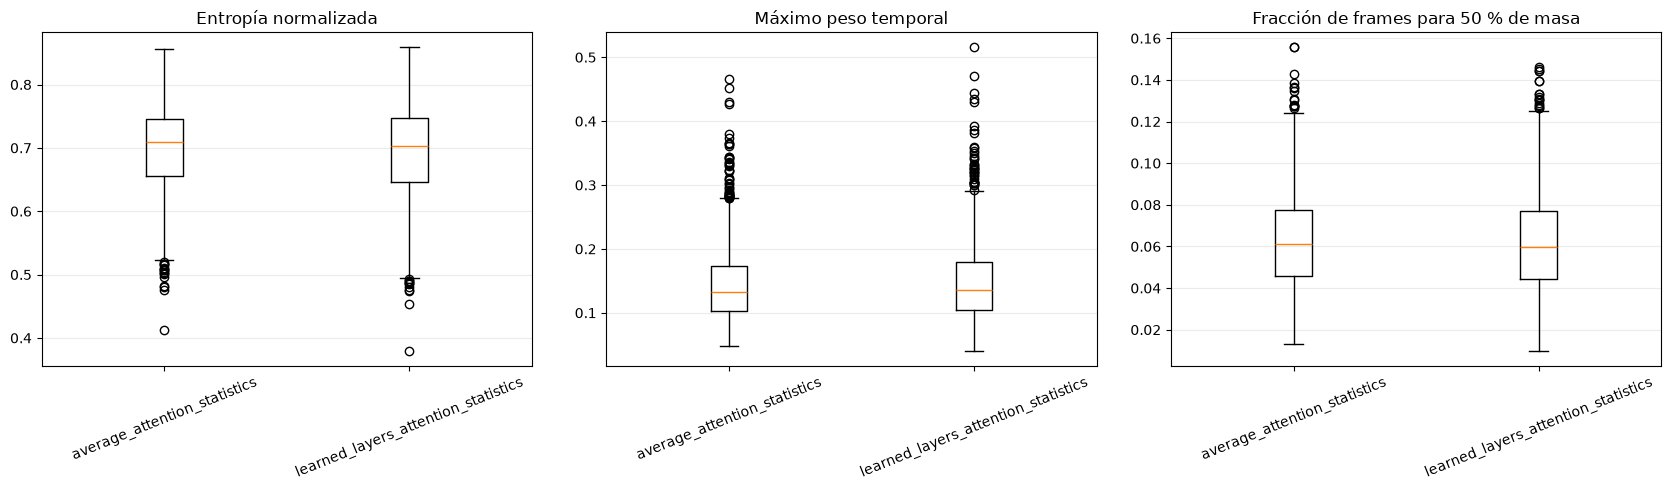

In [9]:
if artifacts.attention_diagnostics.empty:
    print("Sin diagnósticos de atención.")
else:
    fig, _ = plot_attention_diagnostics(
        artifacts.attention_diagnostics,
        configurations=ATTENTION_CONFIGURATIONS,
        protocol=PROTOCOL_INDEPENDENT,
        target=TARGET_EMOTION_ORIGINAL,
    )
    plt.show()

## 8. Matrices OOF: referencia frente a mejor atención

La variante de atención se selecciona por balanced accuracy media. La tercera matriz muestra el cambio normalizado candidato − referencia.

Esta comparación permite detectar ganancias o pérdidas específicas por emoción aunque la métrica global cambie poco.

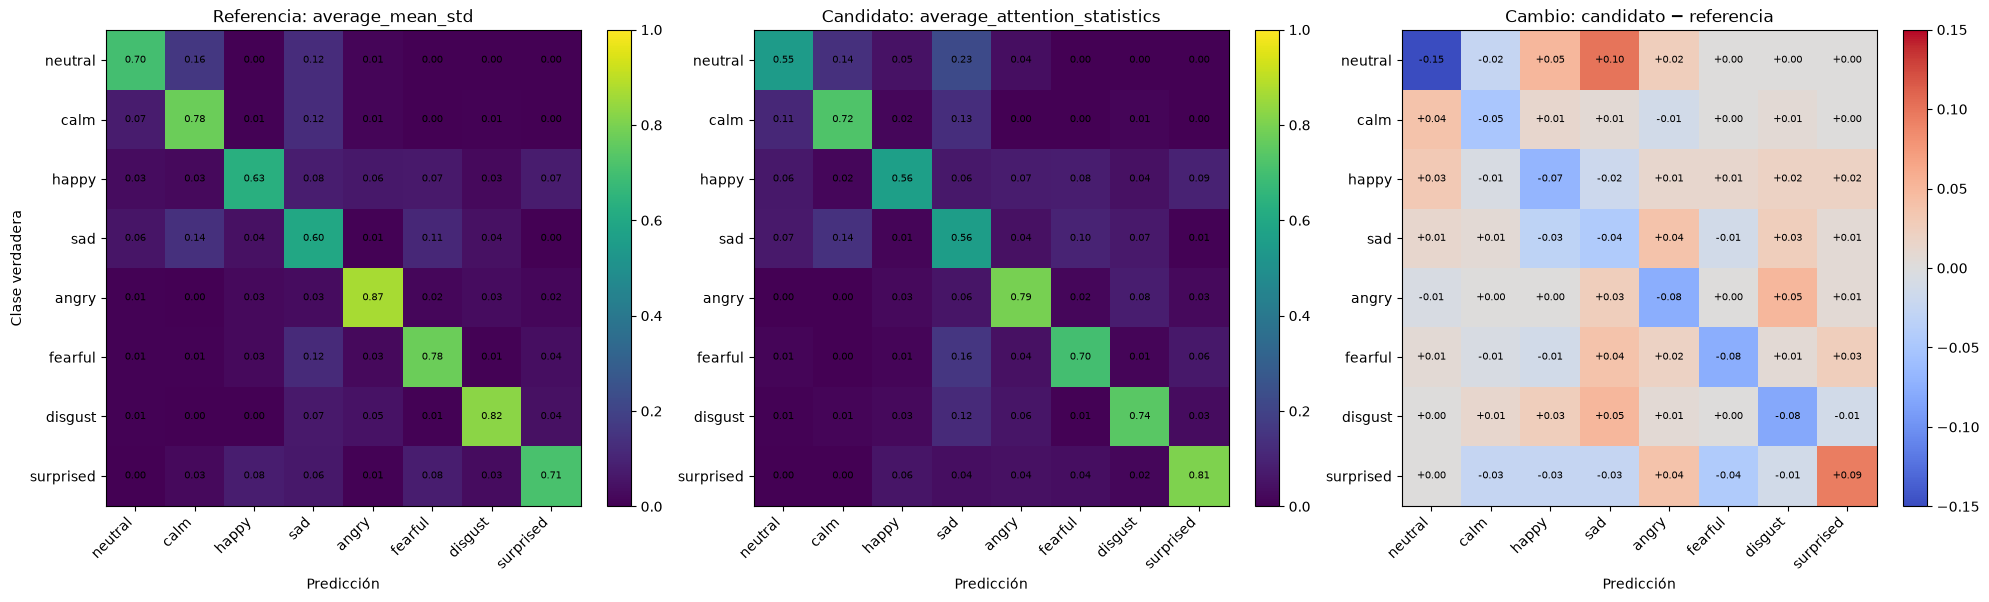

In [10]:
baseline_predictions = select_oof_predictions(
    artifacts.predictions,
    protocol=PROTOCOL_INDEPENDENT,
    target=TARGET_EMOTION_ORIGINAL,
    refinement="average_mean_std",
    representation="wav2vec_temporal",
    model="logistic_regression",
    splits=splits,
    fold_column="fold_speaker_independent",
)
attention_predictions = select_oof_predictions(
    artifacts.predictions,
    protocol=PROTOCOL_INDEPENDENT,
    target=TARGET_EMOTION_ORIGINAL,
    refinement=best_attention,
    representation="wav2vec_multilayer_sequence",
    model="attentive_statistics",
    splits=splits,
    fold_column="fold_speaker_independent",
)

fig, _ = plot_confusion_comparison(
    baseline_predictions,
    attention_predictions,
    labels=LABELS,
    baseline_name="average_mean_std",
    candidate_name=best_attention,
)
plt.show()

### Lectura

La matriz diferencial es la principal evidencia para discutir si la atención redistribuye errores entre clases. Mejoras aisladas en una emoción no justifican por sí solas reemplazar la referencia si se compensan con pérdidas equivalentes en otras clases o con mayor inestabilidad entre hablantes.

## 9. Atención temporal en ejemplos OOF

Se seleccionan de forma determinista hasta tres casos: error corregido, acierto compartido y error persistente. Cuando existen probabilidades, se priorizan ejemplos con mayor ganancia de probabilidad para la clase verdadera.

La grilla temporal de atención se aproxima sobre la duración del audio y se contrasta con RMS únicamente como referencia visual. La figura es ilustrativa y no constituye una explicación causal.

c:\Users\alega\OneDrive\Documentos\std\Speech_Emotion_Recognition\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


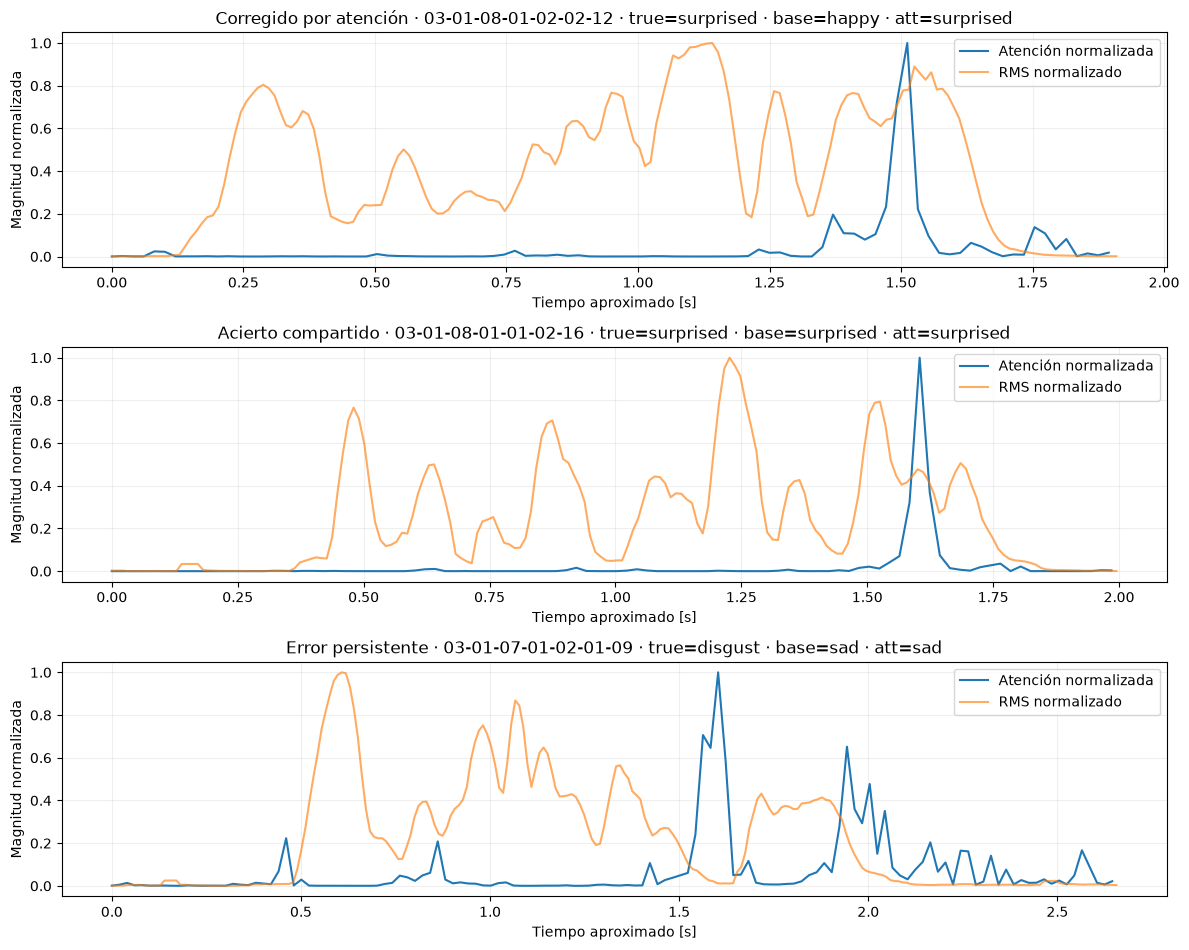

In [11]:
if not artifacts.attention_weights:
    print("Sin pesos de atención persistidos.")
else:
    examples = select_temporal_examples(
        baseline_predictions,
        attention_predictions,
        attention_weights=artifacts.attention_weights,
        candidate_name=best_attention,
        labels=LABELS,
        max_examples=3,
    )
    if examples.empty:
        print("No se encontraron ejemplos OOF alineados.")
    else:
        fig, _ = plot_temporal_examples(
            examples,
            metadata=metadata,
            attention_weights=artifacts.attention_weights,
            candidate_name=best_attention,
            resolve_path_fn=resolve_path,
        )
        plt.show()

## Conclusión metodológica

Bajo el protocolo speaker-independent evaluado, las representaciones con mezcla aprendida de niveles y atención temporal no aportaron una mejora robusta respecto de la representación estática average_mean_std. Aunque la atención aprendió distribuciones temporalmente selectivas y mejoró el recall de la clase surprised, su incorporación redujo la balanced accuracy media, aumentó la sensibilidad a la inicialización y degradó el recall de la mayoría de las emociones. La mezcla aprendida de capas mostró una preferencia moderada por niveles intermedios de wav2vec, pero permaneció próxima al promedio uniforme y no produjo una ventaja consistente entre outer folds. En consecuencia, se selecciona average_mean_std como representación SSL para evaluar el modelo final en test y proceder hacia un domain shift.